# 08 — QGIS Exercise: LiDAR DTM, Hillshading, and α–β Run-out for Debris Flows

**Short course:** *Geomorphological Hazards of Slopes* &nbsp;•&nbsp; University of Silesia in Katowice &nbsp;•&nbsp; 2 ECTS

*Lecturer: Ola Fredin*

---

Operational landslide mapping is done in GIS such as **QGIS**, not in Python. Field geologists, consultants, and national geological surveys all work in a desktop GIS, because that is where the data lives, where the styling is fast, and where the symbology is shareable across a team. This notebook is therefore a **guided QGIS lab**, not a Python walkthrough. You will open a real 1 m LiDAR DTM, render a hillshade, digitise a small inventory of debris-flow tracks and deposits, and finish by predicting their run-out lengths using an α–β relationship.

The notebook itself acts as your **lab handout**: every step in QGIS gets its own markdown block with menu paths, parameter values, and a slot for a screenshot. The only Python in the whole notebook is a short cell at the end that converts the β angles you measured in QGIS into predicted run-out distances.

> ⚠️ **Unpublished material — do not circulate.** The α–β coefficients used in §6 and §7 of this notebook come from Nora Andreassen's *unpublished* MSc thesis (NTNU, June 2026). They are shared here with the author's permission for course use only. **Do not redistribute, repost, or cite outside the course** until the work is formally published. If you want to refer to the result in your own work, contact Ola Fredin first.

## About this notebook

**Learning objectives.** By the end of this exercise the student will be able to:

1. Load a 1 m bare-earth LiDAR DTM into QGIS and render a multi-azimuth hillshade for landslide mapping.
2. Digitise debris-flow source areas, tracks, and deposits as point/line/polygon shapefiles with a consistent attribute schema.
3. Extract topographic parameters (source elevation, toe elevation, fall height *H*, horizontal length *L*, slope angle β) directly from the DTM.
4. Apply the α–β method to predict run-out length, and compare predicted vs. observed values.

**Prerequisites.** Notebook 07 (debris-flow run-out theory) for the mechanical context. No prior QGIS experience is assumed; every step is spelled out.

**Software.** QGIS 3.34 LTR or newer (free, [qgis.org/download](https://qgis.org/download)). No paid plugins required. The *Profile Tool* plugin is useful but optional.

**Deliverables.** Each student submits: (i) a screenshot of their hillshade with the mapped features overlaid, (ii) the three shapefiles (sources, tracks, deposits), and (iii) a one-paragraph interpretation of the predicted vs. observed run-out comparison.

## 1. Data — what you need on disk before you start

You will work with a 1 m bare-earth LiDAR DTM and a 0.5 m CIR orthophoto for the study area, plus an (initially empty) project folder for the shapefiles you will create.

**Study area.** Skamsdalen, central Norway — a glacially scoured U-shaped valley with approximately **1000 m of local relief**. The northern valley side displays numerous active debris flows originating in till that is about **0.5–4 m thick**. This till was deposited during the Weichselian deglaciation approximately **10 000 years ago** and is now being mobilised by gravitational processes.

**DTM tile.**

- Source: [hoydedata.no](https://hoydedata.no) (Kartverket national LiDAR archive — free download for Norway)
- Filename: e.g. `skamsdalen_dtm_1mC.tif`
- Resolution: 1 m (bare-earth, last-return classification)
- CRS: **EPSG:5973** (ETRS89 / ETRS89 / UTM zone 33N + NN2000 height + NN2000 height)
- Coverage: Skamsdalen valley and the debris-flow-bearing northern slope

**CIR orthophoto.**

- Source: [norgeibilder.no](https://norgeibilder.no) (Geovekst programme — free download for Norway)
- Filename: e.g. `skamsdalen_cir_0.5mC.tif`
- Resolution: 0.5 m
- Bands: Near-infrared (band 1), Red (band 2), Green (band 3) — a **false-colour infrared (CIR)** composite
- Importantly: active debris-flow tracks lack dense vegetation, so they appear in **cyan** against the **red** of undisturbed vegetated terrain. This makes it much easier to identify debris-flow starting points and track margins before you digitise on the hillshade.
- CRS: **EPSG:5973** (same as DTM — no reprojection needed)

**Suggested project folder structure.**

```
qgis_lab_08/
  data/
    skamsdalen_dtm_1mC.tif      ← the 1 m LiDAR DTM from hoydedata.no
    skamsdalen_cir_0.5mC.tif    ← the 0.5 m CIR orthophoto from norgeibilder.no
  layers/                       ← created during the exercise
    debris_flow_sources.shp
    debris_flow_tracks.shp
    debris_flow_deposits.shp
  Skamsdalen_project.qgz                   ← the QGIS project file
```

> *[Insert screenshot: final folder layout in Windows Explorer / Finder.]*

## 2. Step 1 — Load the LiDAR DTM and CIR orthophoto into QGIS

**Goal.** Get the 1 m DTM and 0.5 m CIR orthophoto into a fresh QGIS project with CRS set to **EPSG:5973 (ETRS89 / UTM zone 33N + NN2000 height)**, and apply a colour ramp so you can check the elevation data before proceeding.

**Menu path.**

1. *Project → New*, then save immediately as `Skamsdalen_project.qgz` inside your `qgis_lab_08/` folder.
2. *Layer → Add Layer → Add Raster Layer…* → navigate to `data/skamsdalen_dtm_1mC.tif` → Add.
3. Confirm the project CRS in the bottom-right corner of the QGIS window: it should read **EPSG:5973**. If it does not, right-click the DTM layer → *Set CRS → Set Project CRS from Layer*.
4. Right-click the DTM layer → *Properties → Symbology* → set render type to **Singleband pseudocolor**, colour ramp **Turbo** or **Viridis**, classify with 7–10 classes. Click OK.
5. Now add the CIR orthophoto: *Layer → Add Layer → Add Raster Layer…* → navigate to `data/skamsdalen_cir_0.5mC.tif` → Add.
6. Right-click the CIR layer → *Properties → Symbology* → confirm the band assignment: Band 1 → Red channel, Band 2 → Green channel, Band 3 → Blue channel. This renders the near-infrared band as red, making vegetated slopes appear bright red and debris-flow scars cyan. Click OK.
7. In the Layers panel, drag the CIR layer **above** the DTM so it is visible by default. You can toggle it on/off as needed when mapping.

![alt text](Skamsdalen_Turbo-1.png)
Your QGIS screen might look something like this.

## 3. Step 2 — Create a hillshade

**Goal.** Produce a greyscale hillshade that brings the morphology of debris-flow tracks and lobes into relief. We keep one hillshade as the working basemap and optionally stack a second with a different sun azimuth to catch scarps running parallel to the first illumination direction.

**Menu path.**

1. *Raster → Analysis → Hillshade…*
2. Input layer = your DTM (`skamsdalen_dtm_1m.tif`); Z factor = **1.0** (CRS is metric — EPSG:5973 — so no vertical exaggeration needed).
3. Azimuth = **315°**, vertical angle = **45°** — the classical NW illumination that works well for Norwegian valley topography.
4. Output = `layers/hillshade_315.tif`. Click Run.
5. *(Optional but recommended)* Repeat with azimuth **45°** to catch linear features (scarps, lateral levées) running NW–SE that are invisible under NW illumination. Save as `layers/hillshade_045.tif`. In the Layers panel, stack it on top of the first hillshade at **50 % transparency**.
6. Move the hillshade(s) **below** your pseudocolour DTM; set the DTM blending mode to **Multiply** at **60 % opacity** to achieve the classic colour-hillshade look. Move the CIR layer to the top so you can toggle it on and off over the hillshade without disturbing the blend.

**Parameters / things to write down.**

- Sun azimuth(s) used: 315° (primary); 45° (optional second)
- Sun altitude: 45°
- Z-factor: 1.0 (required for metric CRS — do not change)

![alt text](Skamsdalen_blending.png)

Here we are blending the pseudocolor DTM with the Hillshade. You can also do the same with the CIR orthophoto.

![alt text](Skamsdalen_blending2.png)

Here we are blending the CIR image with the Hillshade.

## 4. Step 3 — Map debris-flow features as shapefiles

**Goal.** Build a small inventory of 3–5 debris flows visible on the hillshade. Each flow gets three pieces of geometry: a **source point** at the head, a **track line** running down the channel, and a **deposit polygon** at the runout fan.

### 4.1 Create the three shapefiles

**Menu path.** Repeat the following three times, once per layer:

1. *Layer → Create Layer → New Shapefile Layer…*
2. Set filename, geometry type, **CRS = EPSG:5973 (ETRS89 / UTM zone 33N + NN2000 height)**, and the attribute fields below.

**Suggested attribute schema.**

| Layer | Geometry | Fields |
|---|---|---|
| `debris_flow_sources.shp`  | Point   | `flow_id` (int), `z_source` (real), `notes` (text 100) |
| `debris_flow_tracks.shp`   | LineString | `flow_id` (int), `length_m` (real), `notes` (text 100) |
| `debris_flow_deposits.shp` | Polygon | `flow_id` (int), `z_toe` (real), `area_m2` (real), `notes` (text 100) |

`flow_id` is the join key — each flow gets a unique integer, and the same integer is used across all three layers.

### 4.2 Digitise the features

**Menu path.**

1. *Select layer in Layers panel → toggle editing (pencil icon) → use Add Feature tool.*
2. *Work in this order per flow: source point first, then track line down the channel, then deposit polygon over the fan.*
3. *Enter `flow_id` consistently across the three layers.*
4. *Save edits frequently (Ctrl + S).*

**Tips.**

- Use the **Identify Features** tool (i-icon) on the DTM to read elevations for `z_source` and `z_toe` as you digitise.
- Use the **Snapping toolbar** to make the track line snap to the source point and to the deposit polygon — keeps the geometry tidy.
- Aim for 3–5 mapped flows total, spanning small (a few hundred metres long) to large ( > 1 km) so the α–β analysis has some spread.

> *[Insert screenshot: hillshade with the three mapped layers overlaid, attribute table open.]*

## 5. Step 4 — Extract H, L, and β for each flow

**Goal.** For each mapped flow, derive the three numbers we need for the α–β model:

- **Fall height *H*** — vertical drop from source to deposit toe: $H = z_\mathrm{source} - z_\mathrm{toe}$.
- **Horizontal length *L*** — horizontal distance from source to deposit toe (planar, not along the channel).
- **Overall slope angle β** — the angle of the straight line from source to toe: $\beta = \arctan(H/L)$.

**Menu path — calculate `z_source` and `z_toe` automatically.**

1. *[TODO — Processing Toolbox → search “Sample raster values”. Sample the DTM onto the source points; output goes into a new field. Repeat for the deposit polygons (sample centroid or representative point).]*
2. *[TODO — alternatively, fill `z_source` / `z_toe` manually using the Identify tool while digitising.]*

**Menu path — calculate horizontal length *L*.**

1. *[TODO — open the attribute table of `debris_flow_sources.shp` and `debris_flow_deposits.shp`; for each `flow_id` either: (a) use Measure Line tool source→toe and write the value into a new `L_m` field, or (b) Processing Toolbox → “Distance to nearest hub” / “Join attributes by nearest” to compute it programmatically.]*

**Sanity check.** Channel length (along the track line) should be **longer** than horizontal length *L* (straight-line). If your *L* is longer than the channel length you have a digitising error.

### Output table

Fill the table below as you go in QGIS — we will paste these values into the Python cell in §7 to predict run-out.

| `flow_id` | `z_source` [m] | `z_toe` [m] | *H* [m] | *L* [m] | β = atan(H/L) [°] |
|---|---|---|---|---|---|
| 1 | *[TODO]* | *[TODO]* | *[TODO]* | *[TODO]* | *[TODO]* |
| 2 | *[TODO]* | *[TODO]* | *[TODO]* | *[TODO]* | *[TODO]* |
| 3 | *[TODO]* | *[TODO]* | *[TODO]* | *[TODO]* | *[TODO]* |
| 4 | *[TODO]* | *[TODO]* | *[TODO]* | *[TODO]* | *[TODO]* |
| 5 | *[TODO]* | *[TODO]* | *[TODO]* | *[TODO]* | *[TODO]* |

> *[Insert screenshot: attribute table populated with `z_source`, `z_toe`, `L_m`, `beta_deg`.]*

## 6. Theory — the α–β method 

The **α–β method** is the workhorse empirical run-out model in regional debris-flow and snow-avalanche hazard mapping. It rests on a simple observation: across many events in a given physiographic region, the **overall travel angle** α (from the source to the extreme distal point of the deposit) is **linearly related** to the **slope angle β** (from the source to the point where the channel gradient first flattens to a reference threshold, usually 10°). Steeper paths have steeper deposits, but the relationship is tight enough to predict α from β alone:

$$
\alpha \;=\; a\,\beta + b \qquad (1)
$$

Once α is known, the predicted run-out length *L* from source to toe is fixed by geometry:

$$
L \;=\; \frac{H}{\tan\alpha} \qquad (2)
$$

**Nora's updated coefficients.** The original Lied & Bakkehøi (1980) work fit $a \approx 0.96$, $b \approx -1.4^\circ$ on **13** Norwegian snow-avalanche events. Andreassen (2026, *unpublished MSc thesis*, NTNU) re-fit the relationship on **254 debris slides and debris flows** (*jordskred*) from the Norwegian Water Resources and Energy Directorate's (NVE) national landslide database — an almost twenty-fold expansion of the calibration dataset. Her result is:

$$
\boxed{\;\alpha \;=\; 0.99\,\beta \;-\; 3.53^\circ\;} \qquad (3)
$$

with $R^2 = 0.72$. The 95 % prediction interval for an individual event is approximately $\pm 6.4^\circ$ around the predicted α (essentially constant across the calibrated β range of 20–40°), which corresponds to a residual standard deviation of $\sigma_\alpha \approx 3.3^\circ$. This is wider than the prediction interval of the original 13-event fit — unsurprising given the much larger and more variable dataset — but the new model is statistically more robust because it is not driven by a handful of individual observations.

Comparing the two fits, the Andreassen (2026) relationship generally predicts **slightly higher α** (i.e. **shorter run-outs**) than Lied & Bakkehøi (1980). The original equation is therefore the more conservative choice for hazard zoning, but the updated equation is the more representative choice for a *typical* Norwegian *jordskred*.

> ⚠️ Andreassen (2026) is **unpublished**. Use the coefficients in this notebook for the course exercise only. Do not circulate.

**Important caveats**

- The relationship is **regional**. Coefficients fitted on Norwegian *jordskred/debris flows* should not be exported to the Carpathians (or anywhere else) without re-fitting on a local dataset.
- It is **empirical**, not mechanical — no friction angle, no rheology, no entrainment.
- It gives a **single-number** run-out estimate. For probabilistic hazard zoning use $\alpha \pm 1\sigma$, $\pm 2\sigma$ to draw the orange / red / blue zones.
- It says nothing about lateral spread or impact pressure — only how far the flow travels.

In [1]:
# Setup — only the alpha–beta calculation uses Python.
import numpy as np
import matplotlib.pyplot as plt

from style import apply_style, COLORS, save_figure
apply_style()

## 7. Predict run-out with Nora's α–β — small Python cell

Paste the values from the table in §5 into the arrays below. The cell computes the predicted α and the predicted run-out length *L*₆ from each source, then compares against the observed *L* you measured in QGIS.

In [2]:
# ---- Inputs measured in QGIS (paste from the table in §5) -------------
flow_id  = np.array([1, 2, 3, 4, 5])
H_m      = np.array([np.nan, np.nan, np.nan, np.nan, np.nan])   # fall height, m
L_obs_m  = np.array([np.nan, np.nan, np.nan, np.nan, np.nan])   # observed horizontal length, m
beta_deg = np.array([np.nan, np.nan, np.nan, np.nan, np.nan])   # source-to-toe slope angle, deg

# ---- Nora's alpha-beta coefficients ----------------------------------
# Andreassen (2026, unpublished MSc thesis, NTNU): n = 254 jordskred from NVE database.
# Headline fit:  alpha = 0.989 * beta - 3.527 deg ,  R^2 = 0.72.
# 95% prediction interval ~ +/- 6.4 deg  ->  sigma_alpha ~ 3.27 deg.
# DO NOT CIRCULATE.
A_NORA  = 0.989           # slope of the alpha-beta line (dimensionless)
B_NORA  = -3.527          # intercept of the alpha-beta line (degrees)
S_ALPHA = 3.27            # residual standard deviation of alpha (degrees)

# ---- Predicted alpha and predicted runout length ---------------------
alpha_pred_deg = A_NORA * beta_deg + B_NORA
L_pred_m       = H_m / np.tan(np.radians(alpha_pred_deg))

# +/- 1 sigma envelope on alpha translates into a runout band on L
L_pred_lo_m = H_m / np.tan(np.radians(alpha_pred_deg + S_ALPHA))
L_pred_hi_m = H_m / np.tan(np.radians(alpha_pred_deg - S_ALPHA))

# ---- Pretty-print the comparison -------------------------------------
print(f"{'id':>3}  {'beta':>6}  {'alpha_p':>8}  {'L_obs':>8}  {'L_pred':>8}  {'L_lo':>8}  {'L_hi':>8}")
for i in range(len(flow_id)):
    print(f"{flow_id[i]:>3d}  {beta_deg[i]:>6.1f}  {alpha_pred_deg[i]:>8.1f}  "
          f"{L_obs_m[i]:>8.0f}  {L_pred_m[i]:>8.0f}  {L_pred_lo_m[i]:>8.0f}  {L_pred_hi_m[i]:>8.0f}")

 id    beta   alpha_p     L_obs    L_pred      L_lo      L_hi
  1     nan       nan       nan       nan       nan       nan
  2     nan       nan       nan       nan       nan       nan
  3     nan       nan       nan       nan       nan       nan
  4     nan       nan       nan       nan       nan       nan
  5     nan       nan       nan       nan       nan       nan


<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
C:\Users\hansof\AppData\Local\Temp\ipykernel_19540\1532825804.py:14: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("observed runout length  $L_\mathrm{obs}$  [m]")
C:\Users\hansof\AppData\Local\Temp\ipykernel_19540\1532825804.py:15: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("predicted runout length  $L_\mathrm{pred}$  [m]")
C:\Users\hansof\AppData\Local\Temp\ipykernel_19540\1532825804.py:10: RuntimeWarning: All-NaN slice encountered
  lim_max = np.nanmax([np.nanmax(L_obs_m), np.nanmax(L_pred_hi_m)]) * 1.1
C:\Users\hansof\AppData\Local\Temp\ipykernel_19540\1532825804.py:10: RuntimeWarning: All-NaN axis encountered
  lim_max = np.nanmax([np.nanmax(L_obs_m), np.nanmax(L_pred_hi_m)]) * 1.1


ValueError: Axis limits cannot be NaN or Inf

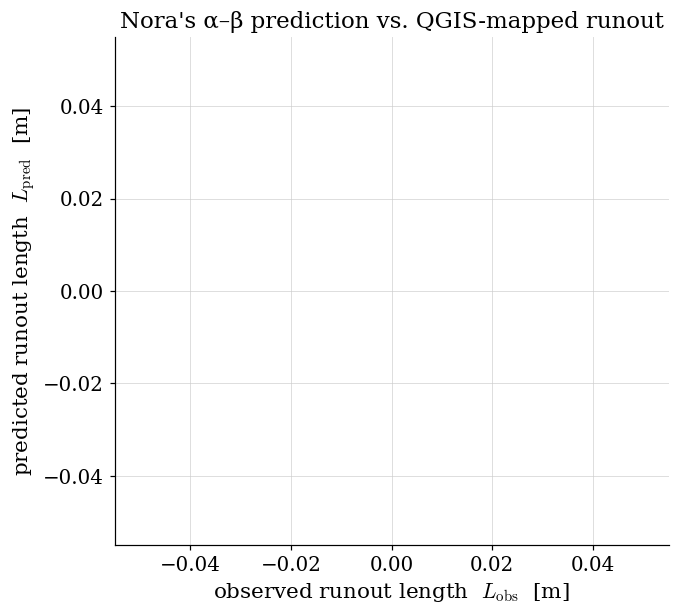

In [3]:
# ---- Plot: observed vs. predicted runout length ---------------------
fig, ax = plt.subplots(figsize=(6.5, 6.0))

ax.errorbar(L_obs_m, L_pred_m,
            yerr=[L_pred_m - L_pred_lo_m, L_pred_hi_m - L_pred_m],
            fmt="o", color=COLORS["accent"], ecolor="grey",
            elinewidth=1.0, capsize=3, label=r"flows  ± 1σ on $\alpha$")

# 1:1 line
lim_max = np.nanmax([np.nanmax(L_obs_m), np.nanmax(L_pred_hi_m)]) * 1.1
ax.plot([0, lim_max], [0, lim_max], color="black", lw=0.8, ls="--",
        label="1 : 1 (perfect prediction)")

ax.set_xlabel("observed runout length  $L_\mathrm{obs}$  [m]")
ax.set_ylabel("predicted runout length  $L_\mathrm{pred}$  [m]")
ax.set_title("Nora's α–β prediction vs. QGIS-mapped runout")
ax.set_xlim(0, lim_max); ax.set_ylim(0, lim_max)
ax.set_aspect("equal")
ax.legend(loc="lower right")

save_figure(fig, "alpha_beta_obs_vs_pred")
plt.show()

## 8. Interpretation

Things to comment on, in one paragraph, in your submission:

- Do the predicted run-out lengths fall within ± 1 σ of the observed ones, or are there systematic over-/under-predictions?
- If there is a systematic bias, what physiographic or geological feature of the study area might explain it? (Confined vs. unconfined channel, lithology, channel slope inflections, vegetation, entrainment of bed material…)
- Would you trust Nora's coefficients for hazard zoning in this catchment as-is, or would you want to re-fit them locally before drawing red/orange/yellow zones?

## Take-aways

- Operational landslide mapping happens in **QGIS**, not Python. Learning the desktop GIS workflow is part of the job.
- A multi-azimuth **hillshade** built from a 1 m bare-earth LiDAR DTM is the foundation of every modern landslide inventory.
- Digitising a small **inventory** — source point, track line, deposit polygon, consistent `flow_id` — turns visual interpretation into data you can analyse.
- The **α–β method** predicts run-out length from a single number (the source-to-toe slope angle β). It is empirical, regional, and gives a deterministic point estimate with a well-defined ± 1 σ envelope around it.
- Andreassen's (2026) re-fit on 254 Norwegian *jordskred* gives a more statistically robust α–β relationship than the original 13-event Lied & Bakkehøi (1980) fit, at the cost of a slightly wider prediction interval. The updated model also predicts *slightly shorter* run-outs on average — so it is less conservative for hazard zoning than the original.

## Voluntary exercises

1. Re-run the α–β prediction in §7 using the original Lied & Bakkehøi (1980) coefficients ($a = 0.96$, $b = -1.4^\circ$). How different are the predicted run-out lengths? In which direction? Which fit would you use for a hazard zonation, and why?
2. Pick one flow whose observed run-out falls well outside the ± 1 σ envelope. Open it in QGIS, look at the channel profile, and propose a physical explanation in 3–4 sentences.
3. Stack a second hillshade with a sun azimuth orthogonal to your first one. Identify one feature visible only in the second hillshade. What does this tell you about single-azimuth mapping?
4. Suppose you only have a 25 m EU-DEM tile instead of the 1 m LiDAR DTM. Which steps of this workflow still work, and which break down? Be specific.

## References

- Lied, K. & Bakkehøi, S. (1980). *Empirical calculations of snow-avalanche run-out distance based on topographic parameters.* Journal of Glaciology, 26(94), 165–177.
- Andreassen, N. (2026). *Fra 13 til 363: revidering og validering av α–β-modellen for utløpslengder av jordskred i Norge.* MSc thesis (TGB4945), Department of Geoscience and Petroleum, Norges Teknisk-Naturvitenskapelige Universitet (NTNU). Supervisor: O. Fredin; co-supervisor: A. Taurisano. **Unpublished — do not circulate.**
- Rickenmann, D. (2005). *Runout prediction methods.* In: Jakob, M. & Hungr, O. (eds), *Debris-flow Hazards and Related Phenomena*, Springer–Praxis, 305–324.
- QGIS Development Team. *QGIS Geographic Information System.* Open Source Geospatial Foundation Project. [qgis.org](https://qgis.org).